<a href="https://colab.research.google.com/github/Zannatul08/CSE499-Capstone-Project/blob/main/CSE499_DDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
## Drug–Drug Interaction Dataset

### Objective
To analyze the structure, quality, and statistical properties of the drug–drug interaction dataset in preparation for:
- Knowledge graph construction
- NLP-based risk extraction
- Severity inference modeling

Dataset size: ~2.9 million interaction records.

In [4]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("drug_interactions.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (2910010, 6)


,drug_1_id,drug_1_name,drug_2_id,drug_2_name,description,severity
0,DB00001,Lepirudin,DB06605,Apixaban,Apixaban may increase the anticoagulant activi...,NaN
1,DB00001,Lepirudin,DB06695,Dabigatran etexilate,Dabigatran etexilate may increase the anticoag...,NaN
2,DB00001,Lepirudin,DB01254,Dasatinib,The risk or severity of bleeding and hemorrhag...,NaN
3,DB00001,Lepirudin,DB01609,Deferasirox,The risk or severity of gastrointestinal bleed...,NaN
4,DB00001,Lepirudin,DB01586,Ursodeoxycholic acid,The risk or severity of bleeding and bruising ...,NaN


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2910010 entries, 0 to 2910009
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   drug_1_id    object 
 1   drug_1_name  object 
 2   drug_2_id    object 
 3   drug_2_name  object 
 4   description  object 
 5   severity     float64
dtypes: float64(1), object(5)
memory usage: 133.2+ MB


In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

,Missing Count,Missing %
severity,2910010,100.0
drug_1_id,0,0.0
drug_1_name,0,0.0
drug_2_id,0,0.0
drug_2_name,0,0.0
description,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
all_drugs = set(df["drug_1_name"]).union(set(df["drug_2_name"]))
print("Total unique drugs (nodes):", len(all_drugs))

Total unique drugs (nodes): 4629


In [10]:
print("Total interaction edges:", len(df))

Total interaction edges: 2910010


In [11]:
print("Self interactions:", (df["drug_1_name"] == df["drug_2_name"]).sum())

Self interactions: 0


In [12]:
df["pair"] = df.apply(lambda x: tuple(sorted([x["drug_1_name"], x["drug_2_name"]])), axis=1)
df = df.drop_duplicates("pair")
df = df.drop(columns=["pair"])

print("Edges after removing reverse duplicates:", len(df))

Edges after removing reverse duplicates: 1455276


In [13]:
n = len(all_drugs)
e = len(df)

density = e / (n*(n-1)/2)
print("Approx network density:", density)

Approx network density: 0.1358610077798584


In [14]:
drug_frequency = pd.concat([df["drug_1_name"], df["drug_2_name"]]).value_counts()
drug_frequency.head(10)

,count
Clozapine,2636
Chlorpromazine,2535
Amitriptyline,2458
Imipramine,2455
Carbamazepine,2423
Cyclosporine,2401
Quinidine,2391
Doxepin,2384
Meloxicam,2381
Clomipramine,2366


In [15]:
sample_df = df.sample(50000, random_state=42)

In [16]:
sample_df["word_count"] = sample_df["description"].apply(lambda x: len(str(x).split()))
sample_df["word_count"].describe()

,word_count
count,50000.000000
mean,14.519900
std,3.081531
min,8.000000
25%,13.000000
50%,15.000000
75%,16.000000
max,28.000000


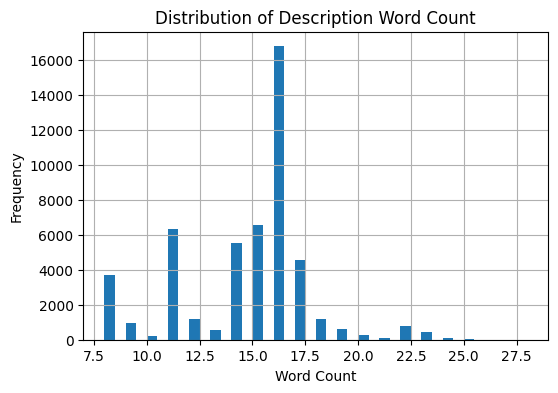

In [17]:
plt.figure(figsize=(6,4))
sample_df["word_count"].hist(bins=40)
plt.title("Distribution of Description Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [18]:
text_data = " ".join(sample_df["description"].astype(str)).lower()
words = re.findall(r'\b[a-zA-Z]+\b', text_data)

Counter(words).most_common(20)

[('of', 50043),
 ('the', 49998),
 ('can', 37391),
 ('when', 37002),
 ('with', 37002),
 ('be', 36966),
 ('combined', 32075),
 ('increased', 26487),
 ('is', 24589),
 ('risk', 21367),
 ('or', 21331),
 ('severity', 21331),
 ('in', 14166),
 ('may', 12573),
 ('serum', 10744),
 ('decreased', 10523),
 ('a', 9632),
 ('decrease', 8753),
 ('excretion', 7453),
 ('level', 7131)]

In [19]:
risk_keywords = ["contraindicated", "bleeding", "fatal", "toxicity", "severe", "risk"]

{word: text_data.count(word) for word in risk_keywords}

{'contraindicated': 0,
 'bleeding': 1516,
 'fatal': 0,
 'toxicity': 497,
 'severe': 2,
 'risk': 21367}

In [ ]:
# reverse_pairs = set(zip(df["drug_1_name"], df["drug_2_name"]))
# reverse_check = [(b,a) for (a,b) in list(reverse_pairs)]

# print("Potential reversed duplicates found (approx check):")

## Key Findings

1. The dataset contains approximately 2.9 million drug interaction records.
2. The interaction network consists of 4,629 unique drugs.
3. After removing reverse duplicates, the graph exhibits a sparse structure.
4. No missing values exist except severity, which is not explicitly provided.
5. Interaction descriptions are short (mean ≈ 15 words) and highly structured.
6. Frequent biomedical risk terminology confirms feasibility of NLP-based risk extraction.
7. Certain drugs act as hubs with high interaction frequency.

Conclusion:
The dataset is structurally clean and suitable for knowledge graph construction and NLP-based severity inference.